<a href="https://colab.research.google.com/github/GustavoGodoy12/A1-JAVA/blob/main/capitulos/jupyter_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt

from skimage import io, color, segmentation, filters, util
from sklearn.cluster import KMeans

SEED = 42
np.random.seed(SEED)

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

(usando fallback skimage.data para imagens/coins.png)
(usando fallback skimage.data para imagens/coffee.png)
coins      : (303, 384) uint8
coins_noisy: (303, 384) uint8
coffee     : (400, 600, 3) uint8


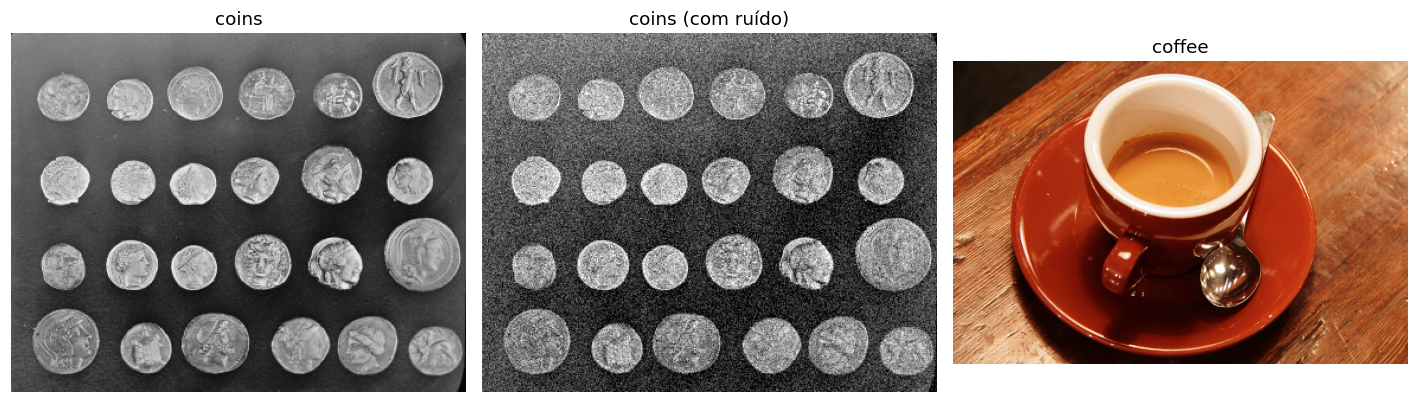

In [3]:

import os
from skimage import data as skdata

def carregar_gray(path_local, fallback_fn):
    if os.path.exists(path_local):
        img = cv2.imread(path_local, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            return img
    print(f'(usando fallback skimage.data para {path_local})')
    return fallback_fn()

def carregar_rgb(path_local, fallback_fn):
    if os.path.exists(path_local):
        bgr = cv2.imread(path_local, cv2.IMREAD_COLOR)
        if bgr is not None:
            return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    print(f'(usando fallback skimage.data para {path_local})')
    return fallback_fn()

coins  = carregar_gray('imagens/coins.png',  lambda: skdata.coins())
coffee = carregar_rgb ('imagens/coffee.png', lambda: skdata.coffee())

# coins com ruido gaussiano
rng = np.random.default_rng(SEED)
coins_noisy = util.random_noise(coins, mode='gaussian', var=0.01, rng=rng)
coins_noisy = (coins_noisy * 255).astype(np.uint8)

print('coins      :', coins.shape, coins.dtype)
print('coins_noisy:', coins_noisy.shape, coins_noisy.dtype)
print('coffee     :', coffee.shape, coffee.dtype)

# preview
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(coins, cmap='gray'); ax[0].set_title('coins')
ax[1].imshow(coins_noisy, cmap='gray'); ax[1].set_title('coins (com ruído)')
ax[2].imshow(coffee); ax[2].set_title('coffee')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

In [7]:
def aplicar_kmeans(img, k=3, seed=SEED):

    if img.ndim == 2:
        X = img.reshape(-1, 1).astype(np.float32)
    else:
        X = img.reshape(-1, 3).astype(np.float32)
    km = KMeans(n_clusters=k, random_state=seed, n_init=5)
    labels = km.fit_predict(X)
    return labels.reshape(img.shape[:2])

In [8]:
def aplicar_felzenszwalb(img, scale=300, sigma=0.8, min_size=80):
    if img.ndim == 2:
        img_in = color.gray2rgb(img)
    else:
        img_in = img
    return segmentation.felzenszwalb(img_in, scale=scale, sigma=sigma,
                                      min_size=min_size)

In [10]:
def kmeans_para_mascara(img, seg, escuro=False):

    n = seg.max() + 1
    means = [img[seg == i].mean() if (seg == i).sum() > 0 else 0 for i in range(n)]
    fg = int(np.argmin(means)) if escuro else int(np.argmax(means))
    return (seg == fg).astype(np.uint8)


def fz_para_mascara(img, seg, escuro=False):

    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        gray = img
    n = seg.max() + 1
    means = np.array([gray[seg == i].mean() if (seg == i).sum() > 0 else 0
                      for i in range(n)])
    thr = filters.threshold_otsu(means)
    fg_regs = means < thr if escuro else means > thr
    return fg_regs[seg].astype(np.uint8)

In [11]:
def iou(a, b):
    a = a.astype(bool); b = b.astype(bool)
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return inter / union if union > 0 else 0.0


def dice(a, b):
    a = a.astype(bool); b = b.astype(bool)
    inter = np.logical_and(a, b).sum()
    s = a.sum() + b.sum()
    return 2 * inter / s if s > 0 else 0.0

Otsu thr coins: 107  |  fg = 38.8% dos pixels
Otsu thr coffee: 103  |  fg = 49.1% dos pixels


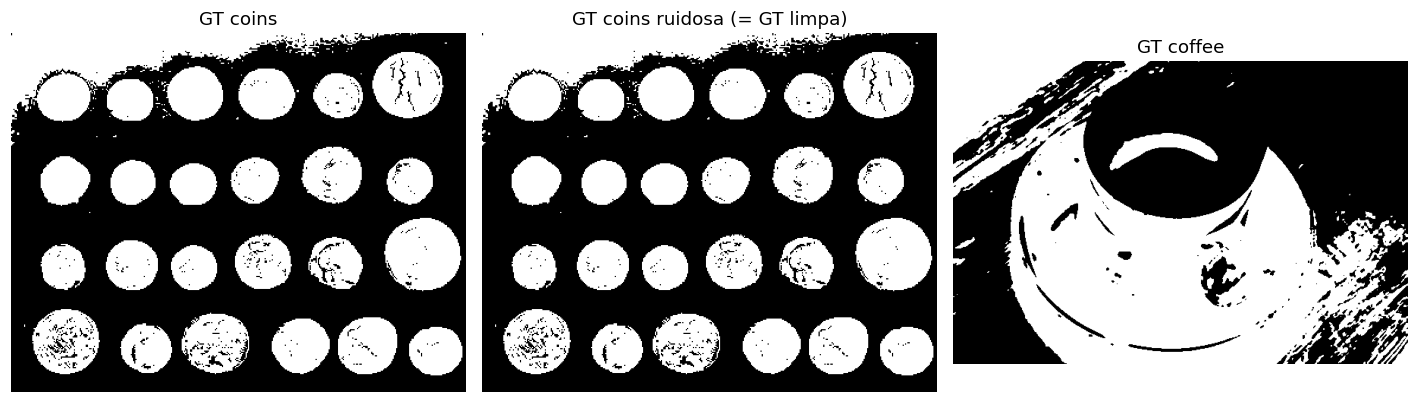

In [13]:
thr_coins = filters.threshold_otsu(coins)
gt_coins = (coins > thr_coins).astype(np.uint8)
print(f'Otsu thr coins: {thr_coins}  |  fg = {gt_coins.mean()*100:.1f}% dos pixels')

gt_coins_noisy = gt_coins

gray_coffee = cv2.cvtColor(coffee, cv2.COLOR_RGB2GRAY)
gray_coffee_blur = cv2.GaussianBlur(gray_coffee, (5, 5), 1.0)
thr_coffee = filters.threshold_otsu(gray_coffee_blur)
gt_coffee = (gray_coffee_blur < thr_coffee).astype(np.uint8)
print(f'Otsu thr coffee: {thr_coffee}  |  fg = {gt_coffee.mean()*100:.1f}% dos pixels')

# visualizar
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(gt_coins, cmap='gray'); ax[0].set_title('GT coins')
ax[1].imshow(gt_coins_noisy, cmap='gray'); ax[1].set_title('GT coins ruidosa (= GT limpa)')
ax[2].imshow(gt_coffee, cmap='gray'); ax[2].set_title('GT coffee')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

In [14]:
def colorir_segmentacao(seg):

    n = seg.max() + 1
    rng_local = np.random.default_rng(123)
    paleta = rng_local.integers(0, 255, size=(n, 3), dtype=np.uint8)
    return paleta[seg]


def rodar(nome, img_para_seg, img_para_mostrar, gt, escuro,
           k=3, fz_params=None, cmap_orig='gray'):
    if fz_params is None:
        fz_params = dict(scale=300, sigma=0.8, min_size=80)

    # k-means
    t0 = time.perf_counter()
    seg_km = aplicar_kmeans(img_para_seg, k=k)
    t_km = (time.perf_counter() - t0) * 1000
    mask_km = kmeans_para_mascara(img_para_seg, seg_km, escuro=escuro)
    iou_km, dice_km = iou(mask_km, gt), dice(mask_km, gt)

    #felzenszwalb
    t0 = time.perf_counter()
    seg_fz = aplicar_felzenszwalb(img_para_seg, **fz_params)
    t_fz = (time.perf_counter() - t0) * 1000
    mask_fz = fz_para_mascara(img_para_seg, seg_fz, escuro=escuro)
    iou_fz, dice_fz = iou(mask_fz, gt), dice(mask_fz, gt)

    print(f'\n--- {nome} ---')
    print(f'k-means       k={k}      t={t_km:7.1f} ms   IoU={iou_km:.3f}   Dice={dice_km:.3f}')
    print(f'felzenszwalb  regs={seg_fz.max()+1:<3}  t={t_fz:7.1f} ms   IoU={iou_fz:.3f}   Dice={dice_fz:.3f}')
    fig, ax = plt.subplots(2, 3, figsize=(13, 7.5))
    if img_para_mostrar.ndim == 2:
        ax[0,0].imshow(img_para_mostrar, cmap=cmap_orig)
    else:
        ax[0,0].imshow(img_para_mostrar)
    ax[0,0].set_title(f'Original — {nome}')
    ax[0,1].imshow(colorir_segmentacao(seg_km))
    ax[0,1].set_title(f'k-means (k={k})')
    ax[0,2].imshow(colorir_segmentacao(seg_fz))
    ax[0,2].set_title(f'Felzenszwalb ({seg_fz.max()+1} regiões)')

    # linha 2
    ax[1,0].imshow(gt, cmap='gray'); ax[1,0].set_title('Ground truth')
    ax[1,1].imshow(mask_km, cmap='gray')
    ax[1,1].set_title(f'k-means: IoU={iou_km:.3f} | Dice={dice_km:.3f} | {t_km:.0f} ms')
    ax[1,2].imshow(mask_fz, cmap='gray')
    ax[1,2].set_title(f'FZ: IoU={iou_fz:.3f} | Dice={dice_fz:.3f} | {t_fz:.0f} ms')

    for a in ax.ravel(): a.axis('off')
    plt.tight_layout()
    plt.show()

    return dict(nome=nome, k=k, t_km=t_km, t_fz=t_fz,
                iou_km=iou_km, iou_fz=iou_fz, dice_km=dice_km, dice_fz=dice_fz,
                regs_fz=int(seg_fz.max()+1))


--- coins ---
k-means       k=2      t=  198.7 ms   IoU=1.000   Dice=1.000
felzenszwalb  regs=78   t=  180.1 ms   IoU=0.770   Dice=0.870


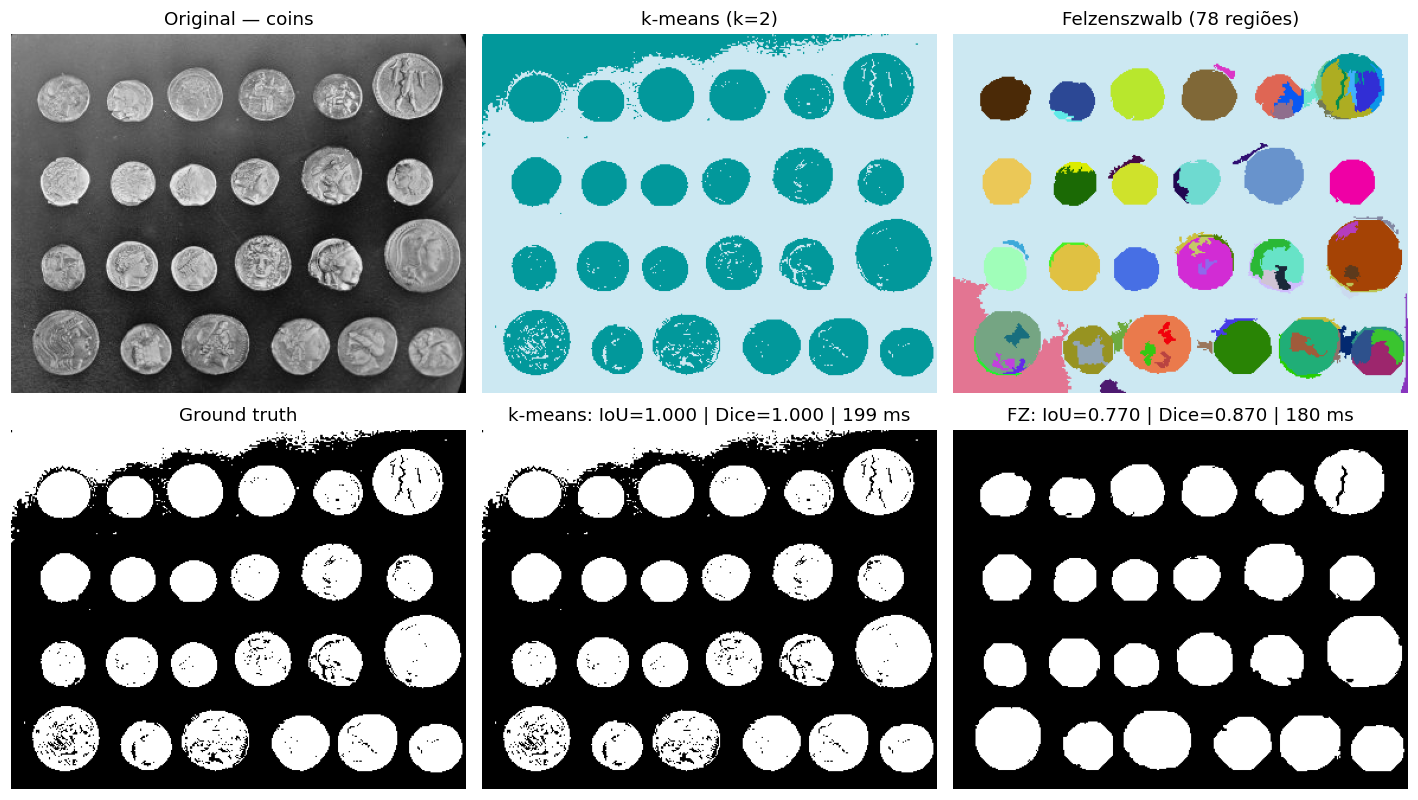

In [15]:
r1 = rodar('coins', coins, coins, gt_coins,
            escuro=False, k=2,
            fz_params=dict(scale=200, sigma=0.6, min_size=80))


--- coins ruidosa ---
k-means       k=2      t=  140.2 ms   IoU=0.772   Dice=0.871
felzenszwalb  regs=62   t=  179.4 ms   IoU=0.724   Dice=0.840


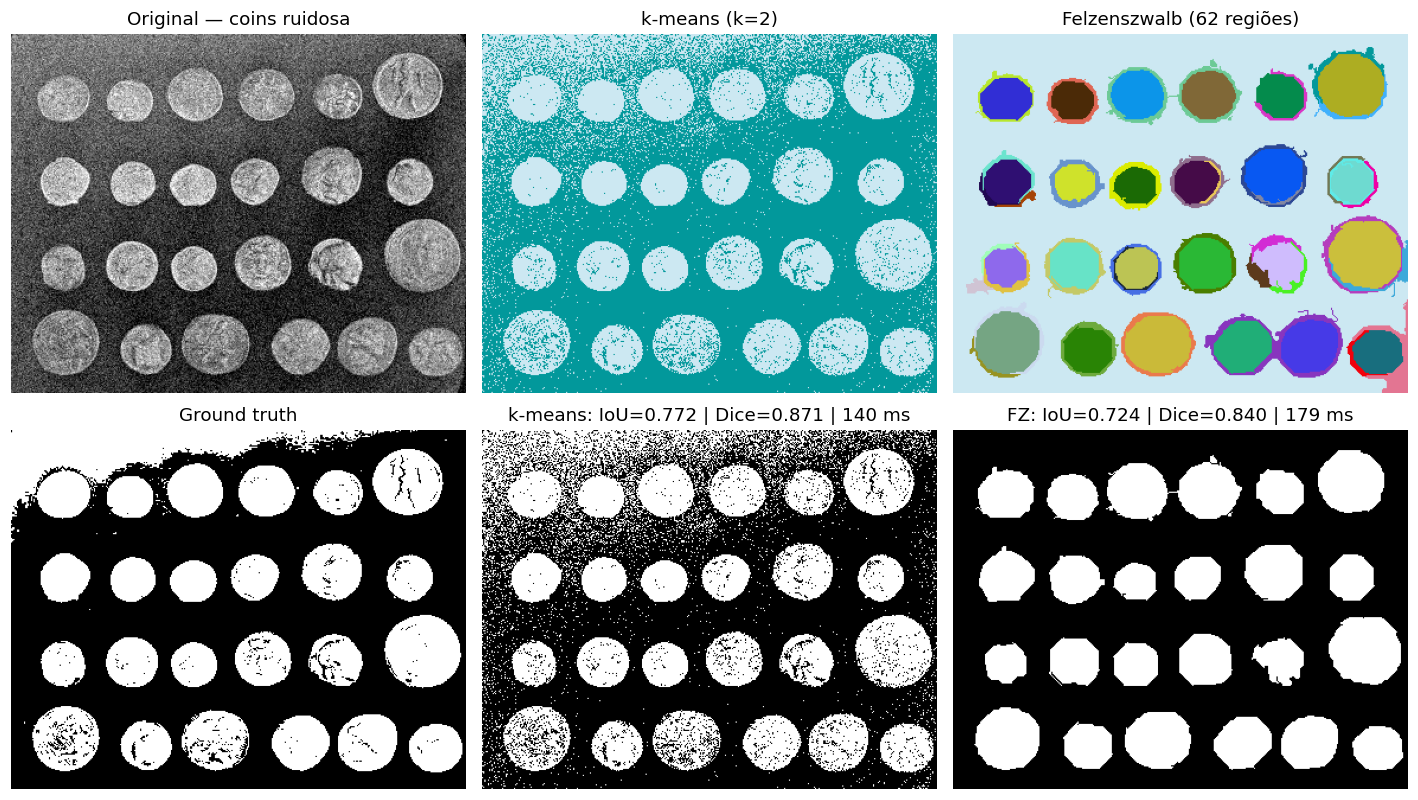

In [16]:
r2 = rodar('coins ruidosa', coins_noisy, coins_noisy, gt_coins_noisy,
            escuro=False, k=2,
            fz_params=dict(scale=300, sigma=1.5, min_size=80))


--- coffee ---
k-means       k=3      t=  641.2 ms   IoU=0.467   Dice=0.637
felzenszwalb  regs=67   t=  417.1 ms   IoU=0.752   Dice=0.858


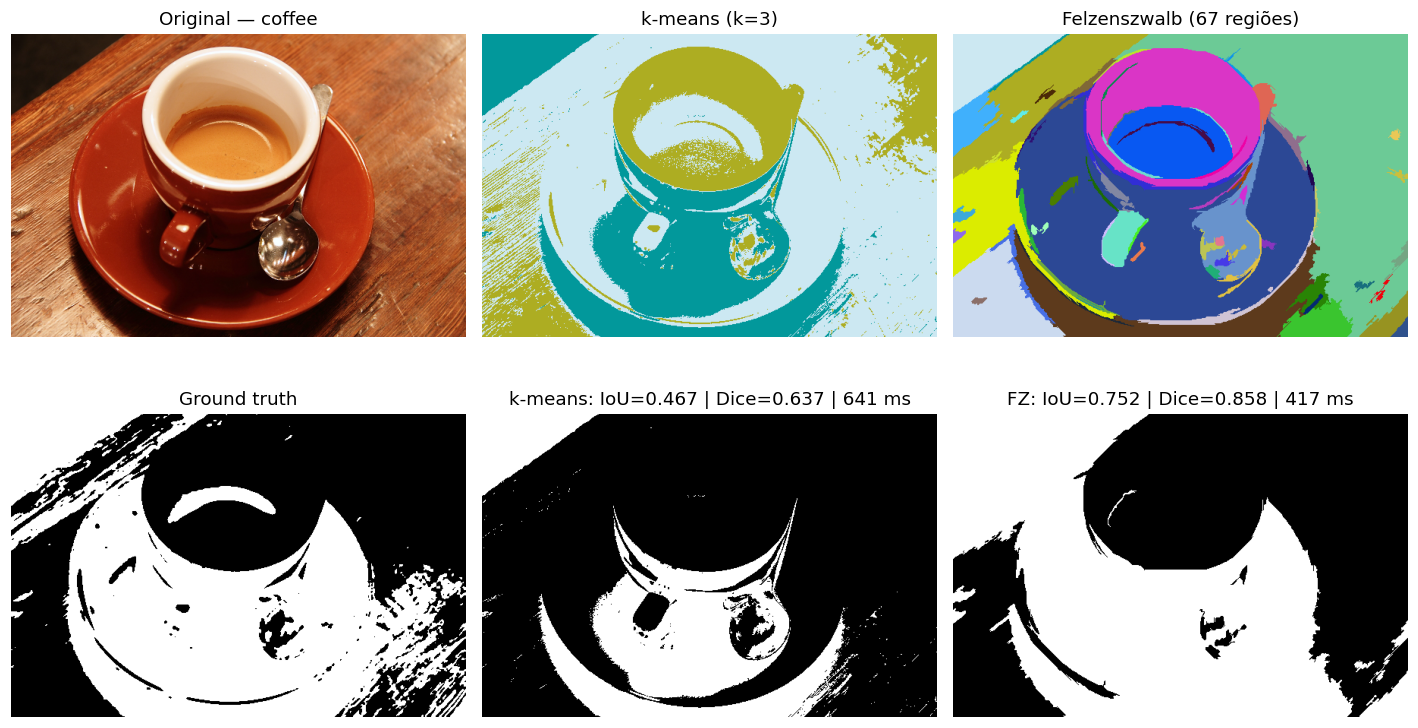

In [17]:
r3 = rodar('coffee', coffee, coffee, gt_coffee,
            escuro=True, k=3,
            fz_params=dict(scale=400, sigma=0.8, min_size=120),
            cmap_orig=None)

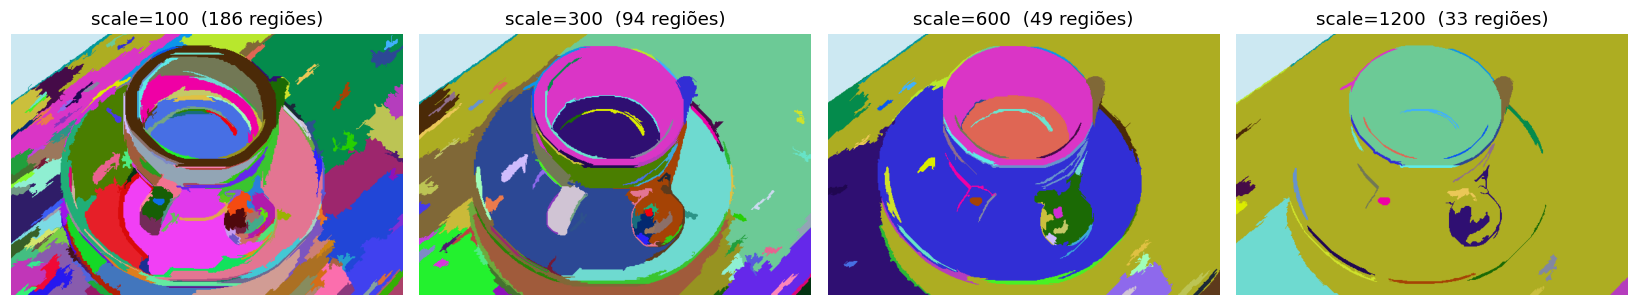

In [18]:
scales = [100, 300, 600, 1200]
fig, ax = plt.subplots(1, len(scales), figsize=(15, 4))
for i, s in enumerate(scales):
    seg = aplicar_felzenszwalb(coffee, scale=s, sigma=0.8, min_size=120)
    ax[i].imshow(colorir_segmentacao(seg))
    ax[i].set_title(f'scale={s}  ({seg.max()+1} regiões)')
    ax[i].axis('off')
plt.tight_layout()
plt.show()

In [19]:
resultados = [r1, r2, r3]

print(f'{"Imagem":<18}{"Método":<16}{"Tempo (ms)":>12}{"IoU":>10}{"Dice":>10}')
print('-' * 66)
for r in resultados:
    print(f'{r["nome"]:<18}{"k-means k="+str(r["k"]):<16}{r["t_km"]:>12.1f}{r["iou_km"]:>10.3f}{r["dice_km"]:>10.3f}')
    print(f'{"":<18}{"Felzenszwalb":<16}{r["t_fz"]:>12.1f}{r["iou_fz"]:>10.3f}{r["dice_fz"]:>10.3f}')
    print()

Imagem            Método            Tempo (ms)       IoU      Dice
------------------------------------------------------------------
coins             k-means k=2            198.7     1.000     1.000
                  Felzenszwalb           180.1     0.770     0.870

coins ruidosa     k-means k=2            140.2     0.772     0.871
                  Felzenszwalb           179.4     0.724     0.840

coffee            k-means k=3            641.2     0.467     0.637
                  Felzenszwalb           417.1     0.752     0.858

